<a href="https://colab.research.google.com/github/PALAK7890/cardiac_arrest_model/blob/main/Cardiac_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/heart-disease-health-indicators-dataset")

print("Path to dataset files:", path)

import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "heart_disease_health_indicators_BRFSS2015.csv"))

print(df.shape)
df.head()

Using Colab cache for faster access to the 'heart-disease-health-indicators-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-health-indicators-dataset
(253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [114]:

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)



import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
df['HeartDiseaseorAttack'].value_counts(normalize=True)

,proportion
HeartDiseaseorAttack,
0.0,0.905814
1.0,0.094186


In [116]:
df = df.drop_duplicates()

# Rename target (cleaner)
df.rename(columns={"HeartDiseaseorAttack": "target"}, inplace=True)

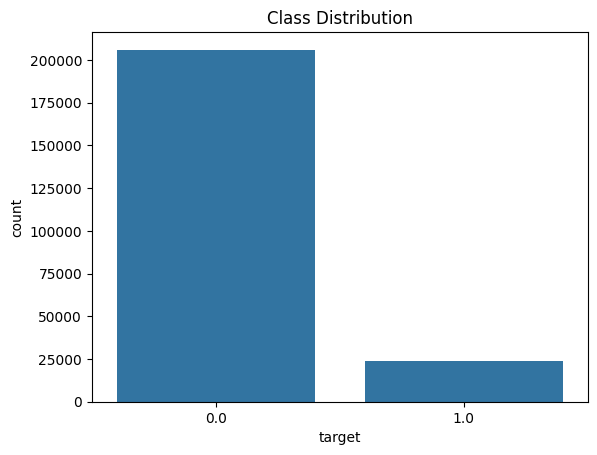

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

In [118]:
X = df.drop("target", axis=1)
y = df["target"]

In [120]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [136]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: 1, 1: 2.5}

In [137]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [138]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [139]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [140]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8655 - loss: 0.4860 - precision_5: 0.3485 - recall_5: 0.3548 - val_accuracy: 0.8689 - val_loss: 0.3140 - val_precision_5: 0.3925 - val_recall_5: 0.4233
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8737 - loss: 0.4636 - precision_5: 0.3850 - recall_5: 0.3824 - val_accuracy: 0.8659 - val_loss: 0.3173 - val_precision_5: 0.3863 - val_recall_5: 0.4420
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8739 - loss: 0.4602 - precision_5: 0.3866 - recall_5: 0.3872 - val_accuracy: 0.8731 - val_loss: 0.3040 - val_precision_5: 0.4038 - val_recall_5: 0.4049
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8750 - loss: 0.4576 - precision_5: 0.3909 - recall_5: 0.3860 - val_accuracy: 0.8735 - val_loss: 0.3112 - val_precision_5: 0.4043 - val_recall_5: 0.3998
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8752 - loss: 0.4564 - precision_5: 0.3931 - recall_5: 0.3929 -

In [141]:
probs = model.predict(X_test).ravel()

1437/1437 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step


In [142]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.40130493


In [143]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

preds = (probs > best_threshold).astype(int)

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("PR-AUC:", average_precision_score(y_test, probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.95      0.87      0.91     41269
         1.0       0.33      0.58      0.42      4688

    accuracy                           0.84     45957
   macro avg       0.64      0.72      0.66     45957
weighted avg       0.88      0.84      0.86     45957

ROC-AUC: 0.8390022721564508
PR-AUC: 0.37962475651436567
Confusion Matrix:
 [[35839  5430]
 [ 1981  2707]]


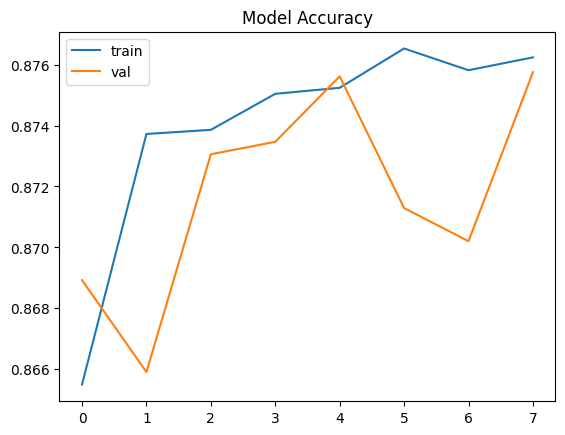

In [144]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [145]:
df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Prob": probs
})

df_results["Risk_Level"] = pd.cut(
    df_results["Predicted_Prob"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

df_results.head()

,Actual,Predicted_Prob,Risk_Level
175726,1.0,0.413428,Medium
227694,0.0,0.137094,Low
85626,0.0,0.081391,Low
141915,0.0,0.185328,Low
93630,0.0,0.202068,Low
